# e6_ext_e1_less_lr

This is the baseline experiment. It includes following components in the model:
* 64x64x3 input size
* 4 Convolutional Layers
* Pooling Layer after each convolutional Layer
* SGD optimizer

### Importing required modules
Importing basic modules for training:
* torch
* datasets and transform
* dataloader

Importing Architecture:
* Architecture

Importing custom utils
* Trainer
* gen_line_charts

In [ ]:
# torch and modules
import torch
import torch.nn as nn
from torchvision import datasets, transforms
from torch.utils.data import DataLoader

# Main architecture
from Architecture import Architecture

# custom utils and modules
from modules.trainer import Trainer
from modules.charts import gen_line_charts

## Load data
Use datasets, transforms and DataLoader to:
* LoadData
* Resize image to 64x64
* transform to tensor

For all three datasets: train and val

In [ ]:
image_size = 64

transform = transforms.Compose([
    transforms.Resize((image_size, image_size)),
    transforms.ToTensor()
])

# make train sets
train_datasets = datasets.ImageFolder("./datasets/train", transform)
train_loader = DataLoader(
    dataset=train_datasets, 
    batch_size=32,
    num_workers=4,
    pin_memory=True,
    shuffle=True,
    persistent_workers=True
)

# make validation sets
val_datasets = datasets.ImageFolder("./datasets/val", transform)
val_loader = DataLoader(
    dataset=val_datasets, 
    batch_size=32,
    num_workers=4,
    pin_memory=True,
    persistent_workers=True
)

## Define and Use Architecture
define a model by calling Architecture class and add layers to it:
* 4 Convolutional Layer each followed with pooling layer
* 1 Flatten Layer followed with a 128 fully connected neural network
* 1 Linear layer to generate 3 class logits

In [3]:
model = Architecture()

Using function to loop adding 4 convolutional layers with pooling layer 

In [4]:
def add_conv_layers(layers=1, skip_pool=0):
    # define in and out channels
    in_channels = 3
    out_channels = 8
    # size
    size = image_size
    # skip pool increase by one for calculation
    skip_pool = skip_pool+1
    # save a trainable parameters
    total_conv_params = 0
    # loop each layers to add on model
    for layer in range(layers):
        # Convolutional Layer
        model.add(
            nn.Conv2d(in_channels, out_channels, 3, 1, 1),
            nn.BatchNorm2d(out_channels),
            nn.ReLU()
        )
        # calculate trainable params
        total_conv_params += (((3*3*in_channels) + 1) * out_channels) + (2*out_channels)
        # Pooling Layer
        if  (layer + 1) % skip_pool:
            model.add(nn.MaxPool2d(2,2))
            size = size/2
        # update in and out channels
        if (layer<layers-1):
            in_channels = out_channels
            out_channels = out_channels*2
    # return total convolutional layer parameters
    return total_conv_params, out_channels, size

Call the `add_conv_layers()` and store parameters

In [5]:
conv_params, out_channels, size = add_conv_layers(4, 0)

# print conv params and out_channels
print(f"Total Trainable Parameters: {conv_params}")
print(f"Final Features: {out_channels}")
print(f"Final Feature size: {size}x{size}")

Total Trainable Parameters: 24768
Final Features: 64
Final Feature size: 64x64


use `model.add()` to add:
* Flatten Layer (64x4x4)
* Hidden Layer (64x4x4->128)
* Output Layer (128->3)

In [6]:
# calculate input
n_in = out_channels*size*size
print(f"Input vector size = {n_in}")

model.add(
    # Flatten
    nn.Flatten(),
    # Hidden Layer
    nn.Linear(n_in, 128),
    nn.ReLU(),
    # Output Layer
    nn.Linear(128, 3),
    nn.ReLU()
)

Input vector size = 262144


Calculating total parameters of the model

In [7]:
total_trainable_parameters = ((n_in*128)+128) + ((128*3)+3)
print(f"Total trainable parameters = {total_trainable_parameters}")

Total trainable parameters = 33554947


### Defining optimizer and Criterion
Optimizer:
* SGD
* learning rate = 3e-4
* no weight decay

Critetion:
* nn.CrossEntropy()

In [8]:
# optimizer
optimizer = torch.optim.SGD(model.parameters(), lr=3e-4)
# criterion 
criterion = nn.CrossEntropyLoss()

## Train the model
Use Trainer Function to train the complete model for 100 epochs

In [9]:
trainer = Trainer(
    model,
    train_loader,
    val_loader,
    optimizer,
    "cuda",
    criterion
)

In [10]:
save_path = "./experiments/e6_ext_e1_less_lr"

In [11]:
metrics = trainer.fit(100, save_path, 1)

EPOCH 5 completed | Training Loss = 0.6088754129943563 | Validation Loss = 0.9449251015981038
EPOCH 10 completed | Training Loss = 0.3396650772930971 | Validation Loss = 0.6464094291130702
EPOCH 15 completed | Training Loss = 0.22106877970161723 | Validation Loss = 0.6191956331332524
EPOCH 20 completed | Training Loss = 0.1605076472928275 | Validation Loss = 0.6429292718569438
EPOCH 25 completed | Training Loss = 0.11773767477985639 | Validation Loss = 0.6345848858356475
EPOCH 30 completed | Training Loss = 0.08995154160839408 | Validation Loss = 0.7085009624560674
EPOCH 35 completed | Training Loss = 0.07288711707093823 | Validation Loss = 0.646871779859066
EPOCH 40 completed | Training Loss = 0.058580363586322584 | Validation Loss = 0.6447699000438054
EPOCH 45 completed | Training Loss = 0.046725856696269406 | Validation Loss = 0.6301010092099507
EPOCH 50 completed | Training Loss = 0.039935158843647185 | Validation Loss = 0.6441505531469981
EPOCH 55 completed | Training Loss = 0.031

## Plot the training metrics
Plotting line chart of training metrics that shows curves of loss, accuracy, precision, recall and f1-score for training set and validation set. 

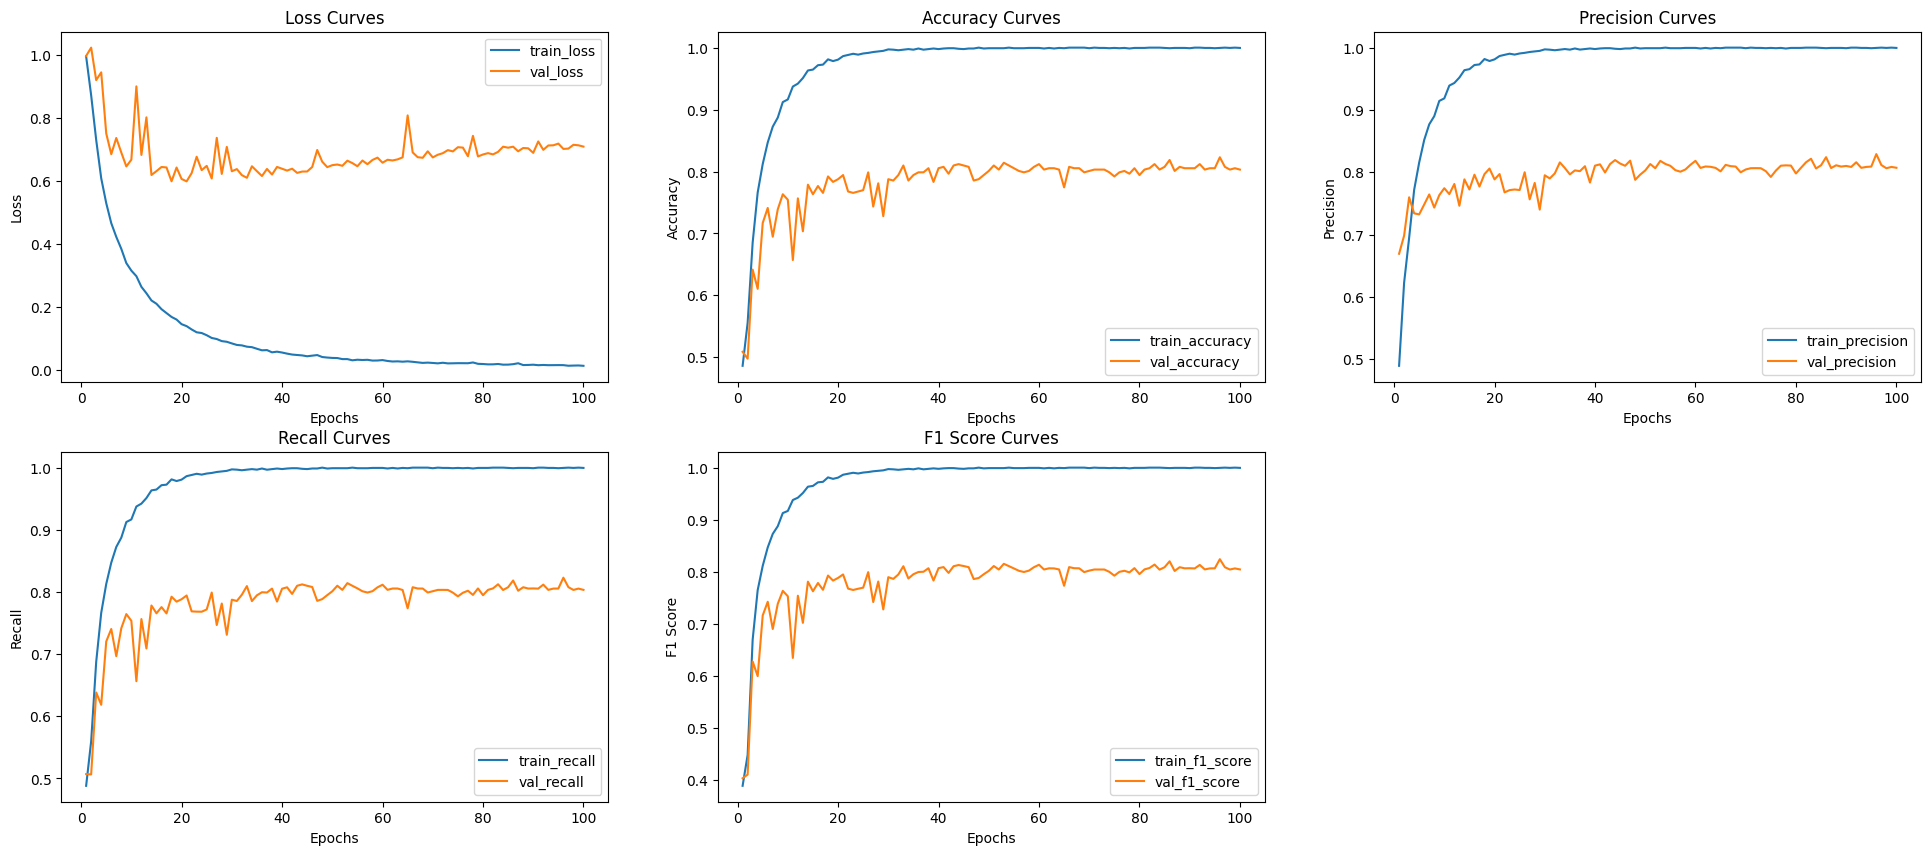

In [12]:
gen_line_charts(metrics, save_path, "training_metrics_graph.png", ["train_", "val_"])

### Model Evaluation
he training loss shows a smooth and continuous decrease throughout the epochs, reducing from approximately 1.0 to near 0.01, indicating that the model effectively learns the training data. The validation loss initially decreases and reaches its lowest points during early and middle epochs, but later becomes unstable and gradually increases. A clear and increasing gap between training and validation loss is observed, indicating that the model is overfitting to the training dataset.

The training accuracy, precision, recall, and F1-score rapidly increase and reach approximately 1.00 during training. The validation metrics also improve quickly, reaching approximately 0.8, but remain stable with fluctuations throughout later epochs. Compared with previous experiments, the validation curves show reduced instability, but the large difference between training and validation performance indicates limited generalization.

Overall, reducing the learning rate improved the training stability compared with earlier experiments, reducing extreme validation fluctuations. However, the model still converges too quickly and achieves near-perfect training performance while validation performance remains lower, showing significant overfitting. The result suggests that learning rate reduction improves optimization stability but does not fully address the overfitting issue in this architecture.